In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator as Pchip

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

Generates HeatMap of the major contributors found in SA: $p_{jack} \, \text{and}\quad w$

In [2]:
def objective_function(npyresult,datafield):

    t_source=np.array(npyresult["timevalues"])
    p_source=np.array(npyresult["values"]) #values, either pressure or other variable
    p_field=datafield["Pint_downhole [MPa]_s"]*1e6 #Pa values

    # sort_idx= np.argsort(t_source) #sortingin case no order in output
    # t_source=t_source[sort_idx]
    # p_source=p_source[sort_idx]

    f= Pchip(t_source,p_source)
    p_interp=f(datafield["Zeit [s]"])

    rmse=np.sqrt(np.mean((p_interp-p_field)**2))

    return rmse

def heat_map(data:pd.DataFrame,par:list=["pjack","wr"],mode:str= 'min') -> None:

    if mode == "min":

        pivot_table = data.groupby(par)['RMSE'].min().unstack()
        pivot_table.index =   pivot_table.index.map(lambda x: f"{x:.1e}")
        pivot_table.columns = pivot_table.columns.map(lambda x: f"{x:.1e}")

        fig, axs= plt.subplots(figsize=(6, 5))
        sns.heatmap(pivot_table, annot=True, fmt=".2e", cmap="viridis_r")
        plt.title(f"Minimum RMSE across variables Grid")

    elif mode == "std":

        pivot_table = data.groupby(par)['RMSE'].std().unstack()
        pivot_table.index = pivot_table.index.map(lambda x: f"{x:.1e}")
        pivot_table.columns = pivot_table.columns.map(lambda x: f"{x:.1e}")

        fig, axs= plt.subplots(figsize=(6, 5))
        sns.heatmap(pivot_table, annot=True, fmt=".2e", cmap="viridis_r")
        plt.title(f"Minimum RMSE across variables Grid")

    else: "input appropiate evaluation 'min' or 'std'"

    return fig

cwd=Path.cwd()

# version 8

In [3]:
field_data_path= cwd/"STIMTEC_example/BH10_20180718_40.6_SR_v2.csv"
field_data=pd.read_csv(field_data_path,header=0)

version="v8"
morris_path=cwd/f"results_{version}/morris_samples_{version}.csv"
morris_df=pd.read_csv(morris_path,header=0)

raw_paths = list(Path(f"{cwd}/results_{version}/results/raw_data").resolve().glob("*.npy"))

file_paths = sorted(
    raw_paths, 
    key=lambda p: int(p.stem.split('_')[2])  
)

vr_list = [np.load(file, allow_pickle=True).item() for file in file_paths]

In [4]:
rmse_c=[]
for value in vr_list:
    rmse=objective_function(value,field_data)
    rmse_c.append(rmse)
rmse_c=np.array(rmse_c)

morris_df1=morris_df.copy()
morris_df1["RMSE"]=rmse_c

#to MPa in this example
morris_df1["pjack"] = morris_df1["pjack"]/1.0e6
morris_df1["wr"]    = morris_df1["wr"]/1.0e6
morris_df1["RMSE"]  = morris_df1["RMSE"]/1.0e6

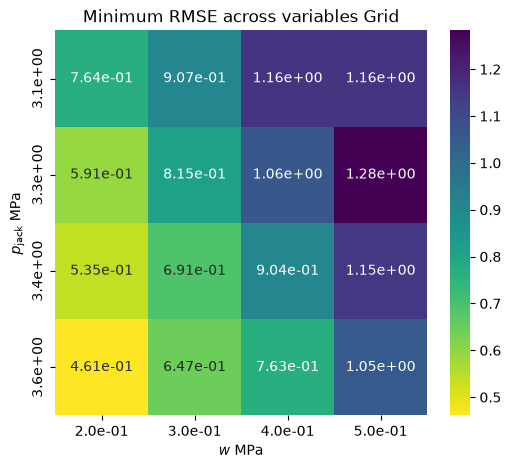

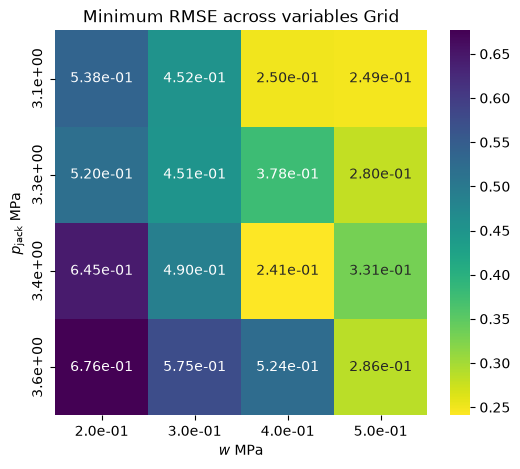

In [ ]:
fig_rmse=heat_map(morris_df1,mode="min")
fig_rmse.axes[0].set(xlabel=r"$w$ MPa", ylabel=r"$p_\mathrm{jack}$ MPa")

# fig_rmse.savefig("rf_heatmin_BH10_20180718_40_6_v8.pdf",format='pdf',
#                  bbox_inches='tight',
#                   pad_inches=0.05)

fig_std=heat_map(morris_df1,mode="std")
fig_std.axes[0].set(xlabel=r"$w$ MPa", ylabel=r"$p_\mathrm{jack}$ MPa")

# fig_std.savefig("rf_heatstd_BH10_20180718_40_6_v8.pdf",format='pdf',
#                  bbox_inches='tight',
#                   pad_inches=0.05)


# version 12

In [6]:
field_data_path= cwd/"STIMTEC_example/BH10_20180718_40.6_SR_v2.csv"
field_data=pd.read_csv(field_data_path,header=0)

version="v12"
morris_path=cwd/f"results_{version}/morris_samples_{version}.csv"
morris_df=pd.read_csv(morris_path,header=0)

raw_paths = list(Path(f"{cwd}/results_{version}/results/raw_data").resolve().glob("*.npy"))

file_paths = sorted(
    raw_paths, 
    key=lambda p: int(p.stem.split('_')[2])  
)

vr_list = [np.load(file, allow_pickle=True).item() for file in file_paths]

In [7]:
rmse_c=[]
for value in vr_list:
    rmse=objective_function(value,field_data)
    rmse_c.append(rmse)
rmse_c=np.array(rmse_c)

morris_df1=morris_df.copy()
morris_df1["RMSE"]=rmse_c

#to MPa in this example
morris_df1["pjack"] = morris_df1["pjack"]/1.0e6
morris_df1["wr"]    = morris_df1["wr"]/1.0e6
morris_df1["RMSE"]  = morris_df1["RMSE"]/1.0e6

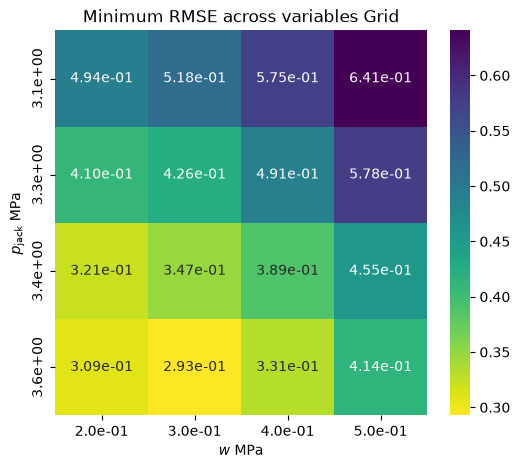

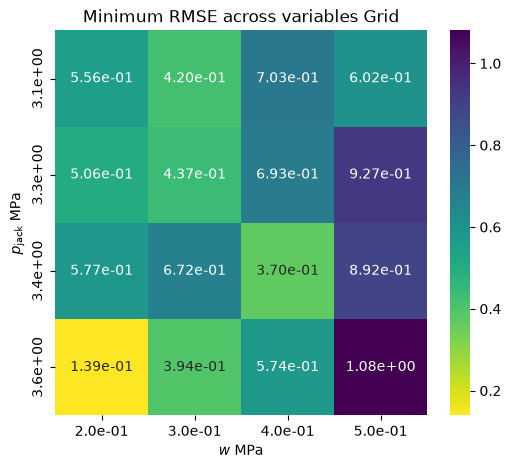

In [ ]:
fig_rmse=heat_map(morris_df1,mode="min")
fig_rmse.axes[0].set(xlabel=r"$w$ MPa", ylabel=r"$p_\mathrm{jack}$ MPa")

# fig_rmse.savefig("rf_heatmin_BH10_20180718_40_6_v12.pdf",format='pdf',
#                  bbox_inches='tight',
#                   pad_inches=0.05)

fig_std=heat_map(morris_df1,mode="std")
fig_std.axes[0].set(xlabel=r"$w$ MPa", ylabel=r"$p_\mathrm{jack}$ MPa")

# fig_std.savefig("rf_heatstd_BH10_20180718_40_6_v12.pdf",format='pdf',
#                  bbox_inches='tight',
#                   pad_inches=0.05)